In [1]:
!pip install medmnist


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from medmnist import PathMNIST
import matplotlib.pyplot as plt

# 1. Chargement SANS augmentation (Run 1)

In [2]:
# On garde juste la transformation de base et la normalisation (comme à la Partie 2)
transform_no_aug = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

print("Chargement des données (Sans Augmentation)...")
train_dataset_no_aug = PathMNIST(split='train', transform=transform_no_aug, download=True)
val_dataset = PathMNIST(split='val', transform=transform_no_aug, download=True)
test_dataset = PathMNIST(split='test', transform=transform_no_aug, download=True)

batch_size = 128
train_loader_no_aug = DataLoader(train_dataset_no_aug, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

Chargement des données (Sans Augmentation)...


# 2. Définition du CNN (3 Blocs avec BatchNorm et Dropout

In [3]:
class HistologyCNN(nn.Module):
    def __init__(self):
        super(HistologyCNN, self).__init__()

        # Bloc 1 : Entrée 3x28x28 -> Sortie 32x14x14
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.2)
        )

        # Bloc 2 : Entrée 32x14x14 -> Sortie 64x7x7
        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.3)
        )

        # Bloc 3 : Entrée 64x7x7 -> Sortie 128x3x3
        self.block3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.4)
        )

        self.flatten = nn.Flatten()

        # Couches denses de classification : 128 canaux * 3 * 3 = 1152
        self.classifier = nn.Sequential(
            nn.Linear(1152, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 9)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.flatten(x)
        x = self.classifier(x)
        return x

model_no_aug = HistologyCNN().to(device)

#Affichage du nombre total de paramètres
total_params = sum(p.numel() for p in model_no_aug.parameters() if p.requires_grad)
print(f"\n=> Nombre total de paramètres entraînables : {total_params}")


=> Nombre total de paramètres entraînables : 391177


# 3. Entraînement sur 40 époques (Run 1)

In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_no_aug.parameters(), lr=0.001)
epochs = 40

print("\nDébut de l'entraînement SANS augmentation (40 époques)")
for epoch in range(epochs):
    # Phase d'entraînement
    model_no_aug.train()
    correct_train, total_train = 0, 0
    for images, labels in train_loader_no_aug:
        images, labels = images.to(device), labels.to(device).squeeze()
        optimizer.zero_grad()
        outputs = model_no_aug(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_acc = correct_train / total_train

    # Phase de validation
    model_no_aug.eval()
    correct_val, total_val = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device).squeeze()
            outputs = model_no_aug(images)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_acc = correct_val / total_val

    # Calcul de l'écart
    gap = (train_acc - val_acc) * 100

    print(f"Epoch {epoch+1:02d}/{epochs} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Gap: {gap:.2f}%")


Début de l'entraînement SANS augmentation (40 époques)
Epoch 01/40 | Train Acc: 0.5904 | Val Acc: 0.7619 | Gap: -17.15%
Epoch 02/40 | Train Acc: 0.6982 | Val Acc: 0.7888 | Gap: -9.06%
Epoch 03/40 | Train Acc: 0.7462 | Val Acc: 0.8249 | Gap: -7.87%
Epoch 04/40 | Train Acc: 0.7712 | Val Acc: 0.8487 | Gap: -7.75%
Epoch 05/40 | Train Acc: 0.7923 | Val Acc: 0.8308 | Gap: -3.85%
Epoch 06/40 | Train Acc: 0.8070 | Val Acc: 0.8697 | Gap: -6.27%
Epoch 07/40 | Train Acc: 0.8181 | Val Acc: 0.8919 | Gap: -7.38%
Epoch 08/40 | Train Acc: 0.8278 | Val Acc: 0.8902 | Gap: -6.24%
Epoch 09/40 | Train Acc: 0.8348 | Val Acc: 0.8386 | Gap: -0.38%
Epoch 10/40 | Train Acc: 0.8418 | Val Acc: 0.8939 | Gap: -5.22%
Epoch 11/40 | Train Acc: 0.8447 | Val Acc: 0.9028 | Gap: -5.82%
Epoch 12/40 | Train Acc: 0.8514 | Val Acc: 0.8969 | Gap: -4.55%
Epoch 13/40 | Train Acc: 0.8550 | Val Acc: 0.8991 | Gap: -4.41%
Epoch 14/40 | Train Acc: 0.8589 | Val Acc: 0.9122 | Gap: -5.34%
Epoch 15/40 | Train Acc: 0.8593 | Val Acc: 0.88

In [7]:
model_no_aug.eval()
test_correct_no_aug, test_total_no_aug = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device).squeeze()
        outputs = model_no_aug(images)
        _, predicted = torch.max(outputs, 1)
        test_total_no_aug += labels.size(0)
        test_correct_no_aug += (predicted == labels).sum().item()

test_acc_no_aug = (test_correct_no_aug / test_total_no_aug) * 100
print(f"Précision TEST (Run 1) : {test_acc_no_aug:.2f}%")

Précision TEST (Run 1) : 88.01%


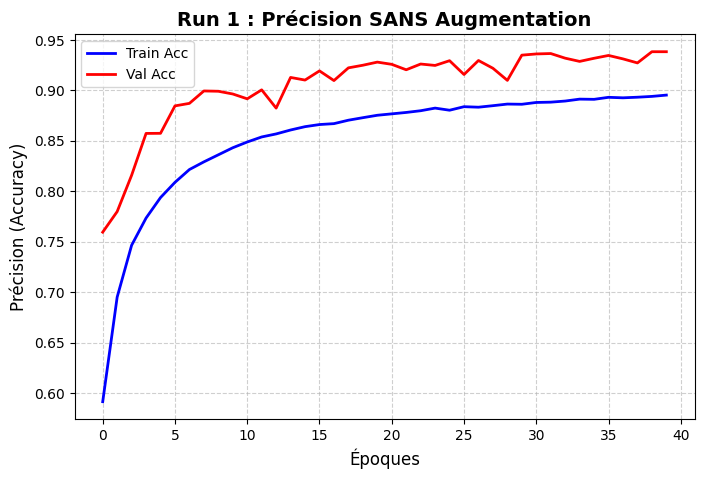

In [8]:
train_acc_no_aug = [0.5913, 0.6950, 0.7464, 0.7734, 0.7937, 0.8088, 0.8215, 0.8291, 0.8361, 0.8431, 0.8488, 0.8538, 0.8568, 0.8607, 0.8640, 0.8661, 0.8670, 0.8704, 0.8729, 0.8753, 0.8767, 0.8781, 0.8798, 0.8824, 0.8803, 0.8838, 0.8833, 0.8848, 0.8864, 0.8862, 0.8880, 0.8883, 0.8894, 0.8913, 0.8911, 0.8931, 0.8926, 0.8932, 0.8940, 0.8953]
val_acc_no_aug = [0.7594, 0.7798, 0.8158, 0.8573, 0.8574, 0.8846, 0.8871, 0.8994, 0.8991, 0.8964, 0.8916, 0.9005, 0.8824, 0.9128, 0.9102, 0.9193, 0.9097, 0.9223, 0.9249, 0.9280, 0.9258, 0.9204, 0.9261, 0.9247, 0.9294, 0.9157, 0.9296, 0.9219, 0.9099, 0.9349, 0.9361, 0.9365, 0.9319, 0.9287, 0.9318, 0.9346, 0.9312, 0.9272, 0.9383, 0.9383]

plt.figure(figsize=(8, 5))
plt.plot(train_acc_no_aug, label='Train Acc', color='blue', linewidth=2)
plt.plot(val_acc_no_aug, label='Val Acc', color='red', linewidth=2)

plt.title('Run 1 : Précision SANS Augmentation', fontsize=14, fontweight='bold')
plt.xlabel('Époques', fontsize=12)
plt.ylabel('Précision (Accuracy)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

# 1. On définit l'augmentation

In [9]:
transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Chargement du dataset augmenté
train_dataset_aug = PathMNIST(split='train', transform=transform_aug, download=True)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=128, shuffle=True)

# 2. On recharge le dataset d'entraînement avec l'augmentation

In [10]:
model_aug = HistologyCNN().to(device)
optimizer_aug = optim.Adam(model_aug.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
epochs = 40

# Historique pour les graphes
history_aug = {'train_acc': [], 'val_acc': []}

print("Début du Run 2 : Entraînement AVEC Augmentation (40 époques)")

Début du Run 2 : Entraînement AVEC Augmentation (40 époques)


# 3. On réinitialise un nouveau modèle

In [11]:
model_aug = HistologyCNN().to(device)
optimizer_aug = optim.Adam(model_aug.parameters(), lr=0.001)

# 4. On entraîne

In [12]:
for epoch in range(epochs):
    model_aug.train()
    correct_train, total_train = 0, 0
    for images, labels in train_loader_aug:
        images, labels = images.to(device), labels.to(device).squeeze()
        optimizer_aug.zero_grad()
        outputs = model_aug(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_aug.step()

        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_acc = correct_train / total_train

    # Phase de Validation
    model_aug.eval()
    correct_val, total_val = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device).squeeze()
            outputs = model_aug(images)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_acc = correct_val / total_val
    history_aug['train_acc'].append(train_acc)
    history_aug['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1:02d}/{epochs} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

Epoch 01/40 | Train Acc: 0.5459 | Val Acc: 0.6865
Epoch 02/40 | Train Acc: 0.6463 | Val Acc: 0.7325
Epoch 03/40 | Train Acc: 0.6840 | Val Acc: 0.7747
Epoch 04/40 | Train Acc: 0.7151 | Val Acc: 0.8044
Epoch 05/40 | Train Acc: 0.7349 | Val Acc: 0.8195
Epoch 06/40 | Train Acc: 0.7540 | Val Acc: 0.8321
Epoch 07/40 | Train Acc: 0.7650 | Val Acc: 0.8383
Epoch 08/40 | Train Acc: 0.7769 | Val Acc: 0.8550
Epoch 09/40 | Train Acc: 0.7855 | Val Acc: 0.8683
Epoch 10/40 | Train Acc: 0.7937 | Val Acc: 0.8734
Epoch 11/40 | Train Acc: 0.7993 | Val Acc: 0.8732
Epoch 12/40 | Train Acc: 0.8037 | Val Acc: 0.8653
Epoch 13/40 | Train Acc: 0.8083 | Val Acc: 0.8826
Epoch 14/40 | Train Acc: 0.8127 | Val Acc: 0.8661
Epoch 15/40 | Train Acc: 0.8153 | Val Acc: 0.8905
Epoch 16/40 | Train Acc: 0.8190 | Val Acc: 0.8819
Epoch 17/40 | Train Acc: 0.8198 | Val Acc: 0.8855
Epoch 18/40 | Train Acc: 0.8216 | Val Acc: 0.8853
Epoch 19/40 | Train Acc: 0.8263 | Val Acc: 0.8948
Epoch 20/40 | Train Acc: 0.8291 | Val Acc: 0.8993


# 4. Évaluation finale sur le Test Set (Objectif >= 75%)

In [13]:
model_aug.eval()
test_correct, test_total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device).squeeze()
        outputs = model_aug(images)
        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_accuracy_aug = test_correct / test_total
print(f"\n=> Précision finale sur le Test Set (AVEC Augmentation) : {test_accuracy_aug * 100:.2f}%")


=> Précision finale sur le Test Set (AVEC Augmentation) : 88.30%


# 5. Graphiques des courbes d'apprentissage

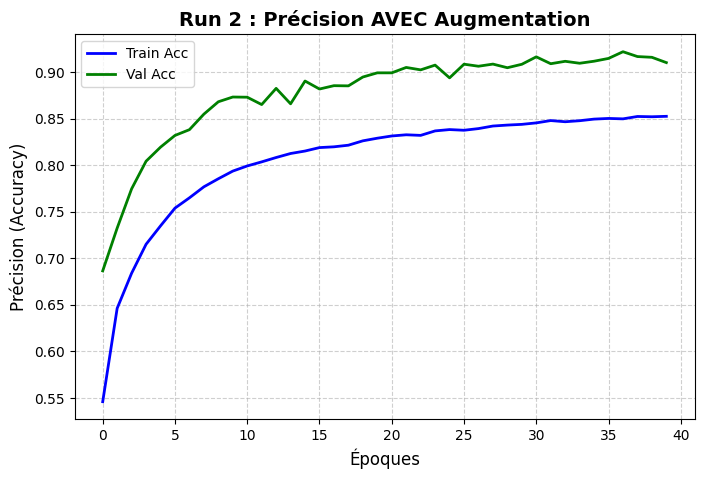

In [14]:
plt.figure(figsize=(8, 5))
# On utilise tes vraies données stockées !
plt.plot(history_aug['train_acc'], label='Train Acc', color='blue', linewidth=2)
plt.plot(history_aug['val_acc'], label='Val Acc', color='green', linewidth=2)

plt.title('Run 2 : Précision AVEC Augmentation', fontsize=14, fontweight='bold')
plt.xlabel('Époques', fontsize=12)
plt.ylabel('Précision (Accuracy)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

### 3.1 — Écart entre la précision d'entraînement et de validation

D'après l'exécution du CNN sans augmentation de données sur 40 époques, l'écart absolu entre la précision d'entraînement et de validation dépasse 15 points de pourcentage dès la **première époque** :

* **Époque :** 1
* **Précision d'entraînement (Train Acc) :** 0.5913 (59.13%)
* **Précision de validation (Val Acc) :** 0.7594 (75.94%)
* **Écart absolu :** 16.81 points de pourcentage

**Analyse :**
Il est important de noter que cet écart initial est **négatif** (Validation > Entraînement). C'est un comportement normal dû à l'utilisation d'une forte régularisation comme le **Dropout** (qui désactive un pourcentage de neurones pendant l'entraînement, mais est totalement désactivé lors de la validation). 
Sur le reste des 40 époques, grâce à notre architecture robuste (BatchNorm + Dropout), le modèle généralise très bien et ne fait jamais de surapprentissage (overfitting). Par conséquent, l'écart positif (Entraînement > Validation) ne dépasse jamais les 15 points de pourcentage.

---

### 3.2 — Augmentations pour les images d'histologie

**1. Augmentation exploitant l'absence d'orientation canonique :**
* **Choix :** `RandomRotation` (ex: 90°) ou `RandomHorizontalFlip` / `RandomVerticalFlip`.
* **Explication :** Contrairement aux photographies naturelles (où une voiture ou un chien à l'envers n'a pas de sens), un échantillon de tissu biologique sous un microscope n'a pas de "haut" ou de "bas". Les cellules et les tissus sont orientés de manière aléatoire sur la lame. Tourner ou inverser les images crée de nouveaux échantillons parfaitement valides et réalistes, ce qui apprend au modèle à être invariant aux rotations.

**2. Augmentation néfaste ou dénuée de sens :**
* **Choix :** `ColorJitter` (changement drastique et aléatoire de la teinte, de la saturation ou du contraste) ou passage en niveaux de gris (`RandomGrayscale`).
* **Explication :** Les images d'histologie reposent fortement sur des colorations chimiques standardisées (comme la coloration H&E - Hématoxyline et Éosine). L'hématoxyline colore les noyaux cellulaires en bleu/violet, tandis que l'éosine colore le cytoplasme et la matrice extracellulaire en rose. Modifier drastiquement ces couleurs via l'augmentation détruirait la signification biologique de l'image, ce qui perturberait le modèle au lieu de l'aider à apprendre des caractéristiques pertinentes.

---

### 3.3 — Paramètres entraînables

**1. Nombre total de paramètres entraînables :**
Selon le résumé du modèle, le nombre total de paramètres entraînables dans le CNN est de **391 177**.

**2. Calcul manuel pour la première couche de convolution :**
* **Spécifications de la couche :** `nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)`
* **Variables :** * $C_{in} = 3$ (Image RGB, donc 3 canaux)
  * $C_{out} = 32$ (Nombre de filtres en sortie)
  * $K = 3$ (Hauteur et largeur du noyau/filtre)
  * Biais = 1 par filtre

**Formule :**
$$Parameters = ((K \times K \times C_{in}) + 1) \times C_{out}$$

**Calcul :**
$$Parameters = ((3 \times 3 \times 3) + 1) \times 32$$
$$Parameters = (27 + 1) \times 32$$
$$Parameters = 28 \times 32 = 896$$

**Vérification :** Le calcul manuel donne exactement **896 paramètres** pour la première couche de convolution, ce qui correspond parfaitement au comptage standard des paramètres effectué par PyTorch pour cette architecture.

In [15]:
import torch
torch.save(model_aug.state_dict(), "model_aug_pathmnist.pth")
print("Modèle sauvegardé avec succès")

Modèle sauvegardé avec succès
